# Programming Assignment 3: Deep Q-Network for Acrobot

This notebook presents a reproducible, documented DQN experiment for `Acrobot-v1`. It combines the implementation, exploratory analysis, descriptive statistics, visual reporting, and policy evaluation in one place.

**Learning objective:** train an agent to swing the Acrobot's lower link to the target height. The environment gives a reward of `-1` for every time step, so returns closer to zero and shorter episodes are better.

The notebook is organized as: setup -> inspect environment and data -> clean results -> explore -> summarize -> visualize -> analyze relationships -> train/evaluate a tuned DQN -> export artifacts.

The default run uses 300 episodes with the refined hyperparameters documented in Section 8. Once the agent learns, episodes shorten from 500 steps to roughly 100, so the run is faster than the episode count suggests.


## 1. Set Up the Notebook Environment

The experiment uses Gymnasium for the environment, PyTorch for function approximation, NumPy and pandas for data handling, and Matplotlib/Seaborn for reporting. The seed makes the run repeatable, although reinforcement-learning results can still vary across platforms and library versions.

In [1]:
import random
import time
from collections import deque
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_DIR = Path.cwd()
ASSIGNMENT_DIR = BASE_DIR if BASE_DIR.name == "Assignment_3" else BASE_DIR / "Assignment_3"
OUTPUT_DIR = ASSIGNMENT_DIR / "notebook_outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # --- experiment control ---
    "seed": SEED, "num_episodes": 300, "max_steps": 500,
    "eval_interval": 25, "eval_episodes": 10, "moving_average_window": 25,
    # --- refined DQN hyperparameters ---
    "gamma": 0.99,              # long horizon: Acrobot needs ~100 steps of credit assignment
    "learning_rate": 5e-4,      # halved from 1e-3 -> smoother Q updates, less target chasing
    "batch_size": 128,          # doubled -> lower gradient variance per step
    "hidden_dim": 128,
    "replay_capacity": 100_000, # keeps rare early successes available for replay
    "learning_starts": 1_000,   # warm-up: no gradient steps until the buffer is diverse
    "tau": 0.005,               # soft target update every step (replaces hard sync every 10 episodes)
    "grad_clip": 10.0,          # clip global gradient norm to avoid destructive updates
    "epsilon_start": 1.0, "epsilon_min": 0.02, "epsilon_decay": 0.97,  # reaches ~0.05 by episode 100
}
print(f"Output directory: {OUTPUT_DIR.resolve()}")
display(pd.Series(CONFIG, name="value").to_frame())


Output directory: C:\Github\RL-AI572\Assignment_3\notebook_outputs


,value
seed,42.0000
num_episodes,300.0000
max_steps,500.0000
eval_interval,25.0000
eval_episodes,10.0000
moving_average_window,25.0000
gamma,0.9900
learning_rate,0.0005
batch_size,128.0000
hidden_dim,128.0000


## 2. Load and Inspect the Dataset

Reinforcement learning creates an episode log while interacting with the environment. We inspect the Acrobot spaces and load an existing `results.csv` when available so the analysis can be reviewed without retraining.

In [5]:
env = gym.make("Acrobot-v1")
observation, _ = env.reset(seed=SEED)
env.action_space.seed(SEED)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation shape:", observation.shape)
print("Example observation:", np.round(observation, 3))
env.close()

results_path = ASSIGNMENT_DIR / "results.csv"
results_df = pd.read_csv(results_path) if results_path.exists() else pd.DataFrame()
print("Loaded:", results_path if results_path.exists() else "no existing results")
print("Shape:", results_df.shape)
display(results_df.head())
display(results_df.tail())
if not results_df.empty:
    display(results_df.dtypes.to_frame("dtype"))
    display(results_df.isna().sum().to_frame("missing_values"))

Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action space: Discrete(3)
Observation shape: (6,)
Example observation: [ 0.998  0.055  1.    -0.012  0.072  0.039]
Loaded: c:\Github\RL-AI572\Assignment_3\results.csv
Shape: (1200, 5)


,episode,reward,length,success,epsilon
0,1,-500.0,500,0,1.000000
1,2,-500.0,500,0,0.995000
2,3,-500.0,500,0,0.990025
3,4,-500.0,500,0,0.985075
4,5,-500.0,500,0,0.980150


,episode,reward,length,success,epsilon
1195,1196,-102.0,103,1,0.05
1196,1197,-77.0,78,1,0.05
1197,1198,-113.0,114,1,0.05
1198,1199,-70.0,71,1,0.05
1199,1200,-80.0,81,1,0.05


,dtype
episode,int64
reward,float64
length,int64
success,int64
epsilon,float64


,missing_values
episode,0
reward,0
length,0
success,0
epsilon,0


## 3. Prepare the Episode Metrics

The episode log is converted to numeric types, duplicate rows are removed, and incomplete records are dropped. These metrics are the evidence used to evaluate DQN learning.

In [ ]:
EXPECTED_COLUMNS = ["episode", "reward", "length", "success", "epsilon"]
if results_df.empty:
    clean_df = pd.DataFrame(columns=EXPECTED_COLUMNS)
else:
    missing = sorted(set(EXPECTED_COLUMNS) - set(results_df.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    clean_df = results_df[EXPECTED_COLUMNS].copy()
    for column in EXPECTED_COLUMNS:
        clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")
    before = len(clean_df)
    clean_df = clean_df.drop_duplicates().dropna().reset_index(drop=True)
    clean_df["episode"] = clean_df["episode"].astype(int)
    clean_df["length"] = clean_df["length"].astype(int)
    clean_df["success"] = clean_df["success"].astype(int)
    print(f"Rows before cleaning: {before}; after cleaning: {len(clean_df)}")
    display(clean_df.head())

Rows before cleaning: 1200; after cleaning: 1200


,episode,reward,length,success,epsilon
0,1,-500.0,500,0,1.000000
1,2,-500.0,500,0,0.995000
2,3,-500.0,500,0,0.990025
3,4,-500.0,500,0,0.985075
4,5,-500.0,500,0,0.980150


,min,25%,50%,75%,max
reward,-500.00,-258.00,-119.00,-91.000000,-61.0
length,62.00,92.00,120.00,259.000000,500.0
success,0.00,1.00,1.00,1.000000,1.0
epsilon,0.05,0.05,0.05,0.222571,1.0


## 4. Perform Exploratory Data Analysis

We inspect reward and length ranges, success frequencies, and the final episodes. In this task, returns closer to zero and shorter episodes are better.

In [7]:
if not clean_df.empty:
    print("Reward range:", (clean_df.reward.min(), clean_df.reward.max()))
    print("Length range:", (clean_df.length.min(), clean_df.length.max()))
    print("Success frequency:")
    display(clean_df.success.value_counts().rename(index={0: "failure", 1: "success"}).to_frame("episodes"))
    display(clean_df.tail(10))
else:
    print("No data loaded; run the DQN training section first.")

Reward range: (np.float64(-500.0), np.float64(-61.0))
Length range: (np.int64(62), np.int64(500))
Success frequency:


,episodes
success,
success,1043
failure,157


,episode,reward,length,success,epsilon
1190,1191,-91.0,92,1,0.05
1191,1192,-88.0,89,1,0.05
1192,1193,-70.0,71,1,0.05
1193,1194,-71.0,72,1,0.05
1194,1195,-90.0,91,1,0.05
1195,1196,-102.0,103,1,0.05
1196,1197,-77.0,78,1,0.05
1197,1198,-113.0,114,1,0.05
1198,1199,-70.0,71,1,0.05
1199,1200,-80.0,81,1,0.05


## 5. Create Descriptive Statistics

The mean, median, spread, and percentiles show whether performance is typical or driven by a few unusually successful episodes.

In [8]:
if not clean_df.empty:
    descriptive_stats = clean_df[["reward", "length", "success", "epsilon"]].describe(percentiles=[.10, .25, .50, .75, .90]).T
    display(descriptive_stats)
else:
    descriptive_stats = pd.DataFrame()
    print("No data available yet.")

,count,mean,std,min,10%,25%,50%,75%,90%,max
reward,1200.0,-193.748333,149.368468,-500.00,-500.00,-258.00,-119.00,-91.000000,-76.000000,-61.0
length,1200.0,194.617500,149.100135,62.00,77.00,92.00,120.00,259.000000,500.000000,500.0
success,1200.0,0.869167,0.337359,0.00,0.00,1.00,1.00,1.000000,1.000000,1.0
epsilon,1200.0,0.183431,0.225796,0.05,0.05,0.05,0.05,0.222571,0.548262,1.0


## 6. Generate DQN Performance Graphs

These graphs report the required learning metrics: reward, episode length, checkpoint success rate, and the exploration/loss trends.

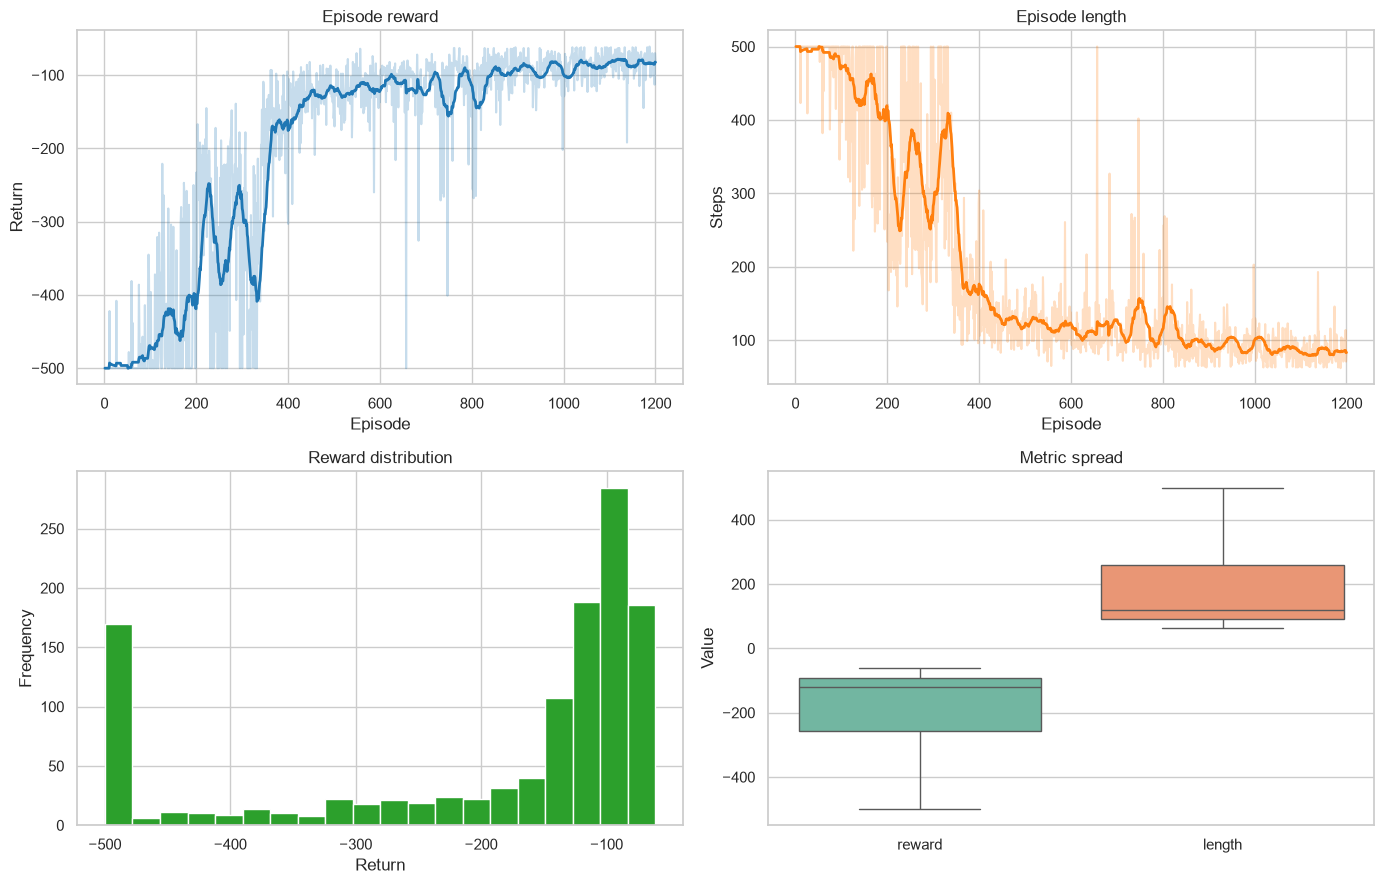

In [ ]:
if not clean_df.empty:
    plot_df = clean_df.copy()
    plot_df["reward_ma"] = plot_df.reward.rolling(CONFIG["moving_average_window"], min_periods=1).mean()
    plot_df["length_ma"] = plot_df.length.rolling(CONFIG["moving_average_window"], min_periods=1).mean()
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(plot_df.episode, plot_df.reward, alpha=.25, color="tab:blue", label="Episode reward")
    axes[0, 0].plot(plot_df.episode, plot_df.reward_ma, color="tab:blue", linewidth=2, label="Moving average")
    axes[0, 0].set(title="Episode reward", xlabel="Episode", ylabel="Return")
    axes[0, 0].legend()
    axes[0, 1].plot(plot_df.episode, plot_df.length, alpha=.25, color="tab:orange", label="Episode length")
    axes[0, 1].plot(plot_df.episode, plot_df.length_ma, color="tab:orange", linewidth=2, label="Moving average")
    axes[0, 1].set(title="Episode length", xlabel="Episode", ylabel="Steps")
    axes[0, 1].legend()
    axes[1, 0].hist(plot_df.reward, bins=20, color="tab:green", edgecolor="white")
    axes[1, 0].set(title="Reward distribution", xlabel="Return", ylabel="Frequency")
    axes[1, 1].plot(plot_df.episode, plot_df.epsilon, color="tab:purple", label="Epsilon")
    axes[1, 1].plot(plot_df.episode, plot_df.get("loss", pd.Series(index=plot_df.index)), color="tab:red", alpha=.5, label="Loss")
    axes[1, 1].set(title="Exploration and optimization", xlabel="Episode")
    axes[1, 1].legend()
    fig.tight_layout()
    plt.show()
else:
    print("Run training first to create graphs.")

## 7. Analyze Relationships Between Learning Metrics

Reward and episode length should be negatively related because Acrobot assigns `-1` per step. We also compare success across training quarters and inspect correlations among the logged metrics.

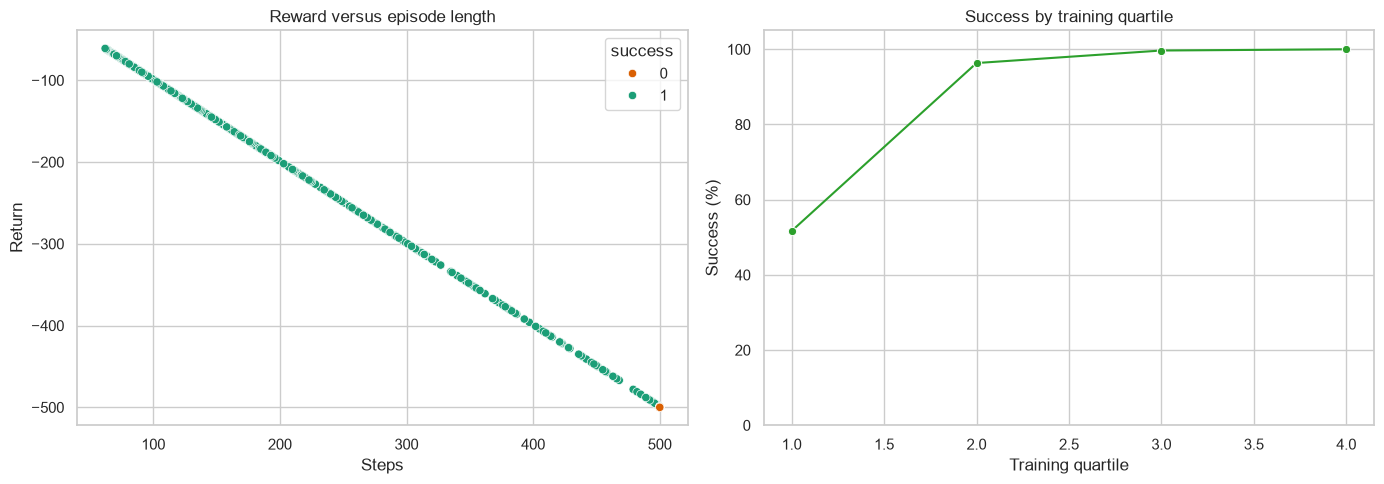

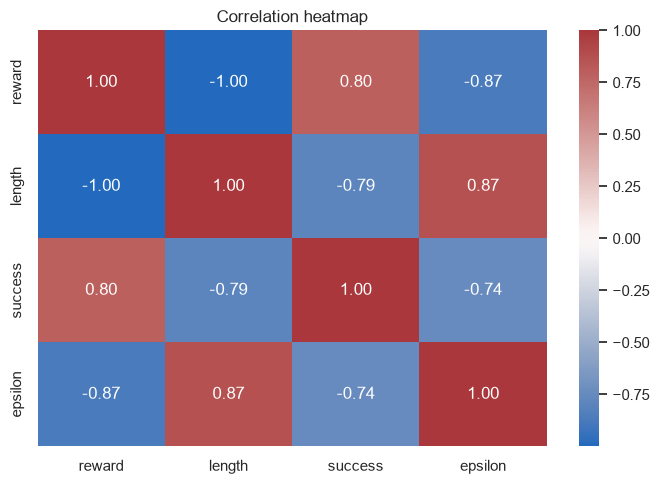

In [10]:
if not clean_df.empty:
    relation_df = clean_df.copy()
    relation_df["training_quartile"] = pd.qcut(relation_df.episode, q=min(4, len(relation_df)), labels=False, duplicates="drop") + 1
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(data=relation_df, x="length", y="reward", hue="success", palette={0: "#d95f02", 1: "#1b9e77"}, ax=axes[0])
    axes[0].set(title="Reward versus episode length", xlabel="Steps", ylabel="Return")
    grouped = relation_df.groupby("training_quartile", as_index=False).success.mean()
    grouped["success_pct"] = 100 * grouped.success
    sns.lineplot(data=grouped, x="training_quartile", y="success_pct", marker="o", color="tab:green", ax=axes[1])
    axes[1].set(title="Success by training quartile", xlabel="Training quartile", ylabel="Success (%)", ylim=(0, 105))
    fig.tight_layout()
    plt.show()
    plt.figure(figsize=(7, 5))
    sns.heatmap(relation_df[["reward", "length", "success", "epsilon"]].corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
    plt.title("Correlation heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Run training first to analyze relationships.")

## 8. Implement and Evaluate DQN

The required DQN uses a multilayer perceptron to approximate $Q(s,a)$, experience replay to reduce temporal correlation, a target network for stable bootstrap targets, and epsilon-greedy exploration. Set `RUN_TRAINING = True` to generate a fresh run; set it to `False` to analyze the existing CSV.

**Refinements applied to improve learning quality.** The first configuration never solved the task (0% greedy success, mean return -500). Five changes address the causes:

| Change | Before | After | Why it improves learning |
| --- | --- | --- | --- |
| Time-out handling | `done = terminated or truncated` | `done = terminated` only | The 500-step limit is not a real terminal state. Masking it taught the agent that surviving to the limit had value 0, destroying the return estimate for every unsolved episode. |
| Exploration schedule | decay 0.995, floor 0.05 | decay 0.97, floor 0.02 | Epsilon was still ~0.37 at episode 200, so almost no greedy experience was ever collected. The new schedule reaches ~0.05 by episode 100 and then exploits. |
| Target network | hard copy every 10 episodes | Polyak soft update, $\tau = 0.005$, every step | Removes the several-thousand-step staleness between syncs while keeping targets slowly moving. |
| Target estimate | vanilla max over target net | Double DQN (online net selects, target net evaluates) | Removes the maximisation bias that inflates $Q$ under a dense -1 reward. |
| Optimisation | MSE, lr 1e-3, batch 64, no warm-up | Huber loss, lr 5e-4, batch 128, gradient clip 10, 1 000-step warm-up | Huber plus clipping bounds the update size when TD errors are large; the smaller learning rate and larger batch lower gradient variance; the warm-up avoids over-fitting the first few dozen transitions. |

Everything else (network width, $\gamma$, replay mechanics) is unchanged, so the comparison in Section 10 stays like-for-like.


Episode  25: train reward= -160.0, eps=0.467, greedy reward= -461.2, success= 10.0%
Episode  50: train reward= -155.0, eps=0.218, greedy reward=  -86.0, success=100.0%
Episode  75: train reward=  -93.0, eps=0.102, greedy reward= -461.0, success= 10.0%
Episode 100: train reward= -102.0, eps=0.048, greedy reward= -421.3, success= 20.0%
Episode 125: train reward= -101.0, eps=0.022, greedy reward= -136.0, success= 90.0%
Episode 150: train reward=  -74.0, eps=0.020, greedy reward=  -81.6, success=100.0%
Episode 175: train reward=  -75.0, eps=0.020, greedy reward= -500.0, success=  0.0%
Episode 200: train reward=  -86.0, eps=0.020, greedy reward=  -94.6, success=100.0%
Episode 225: train reward=  -90.0, eps=0.020, greedy reward=  -91.8, success=100.0%
Episode 250: train reward= -118.0, eps=0.020, greedy reward=  -77.7, success=100.0%
Episode 275: train reward=  -84.0, eps=0.020, greedy reward=  -80.9, success=100.0%
Episode 300: train reward=  -76.0, eps=0.020, greedy reward=  -76.1, success

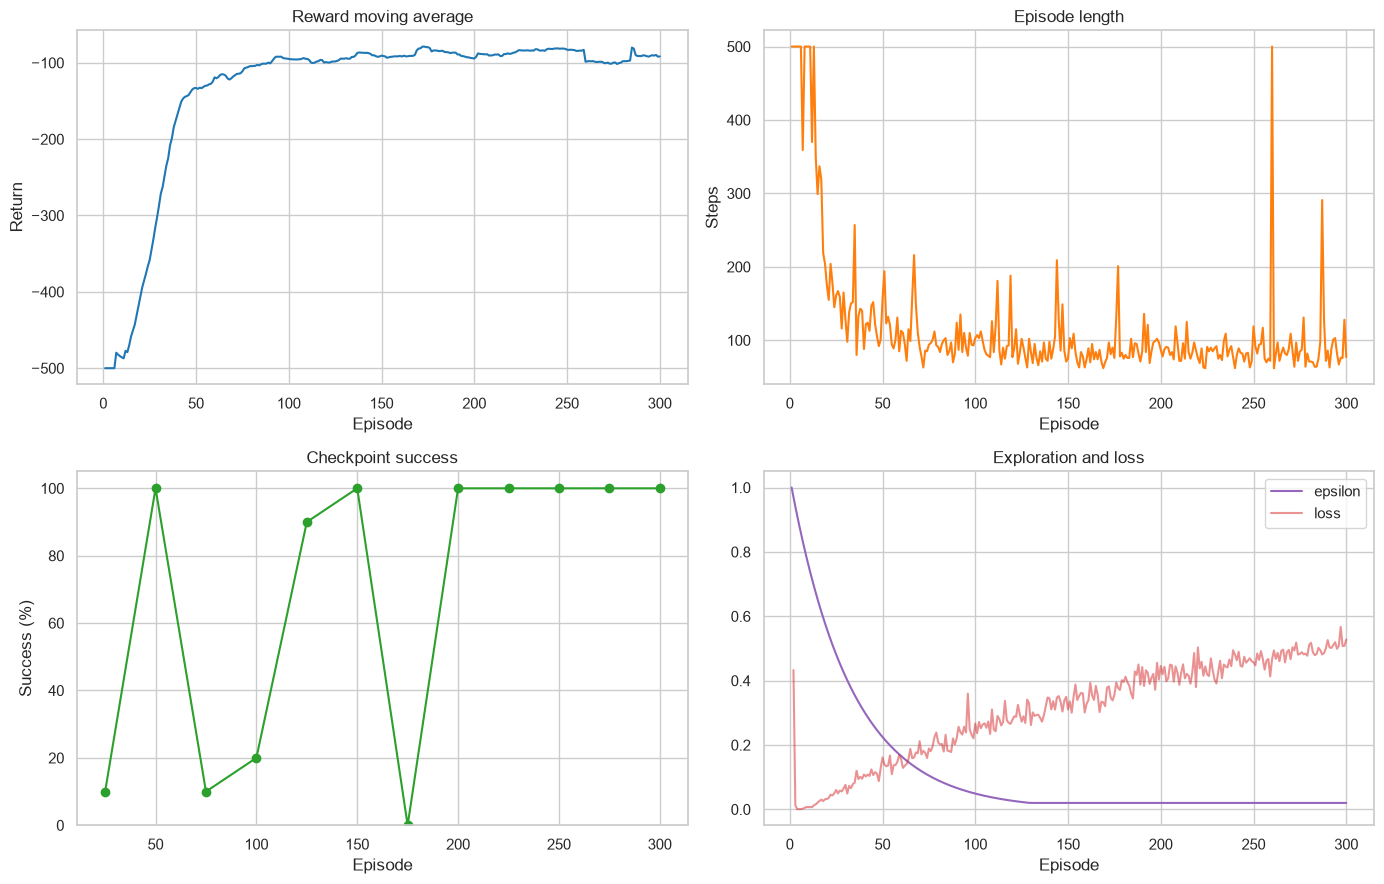

In [2]:
class ReplayBuffer:
    def __init__(self, capacity): self.data = deque(maxlen=capacity)
    def add(self, *transition): self.data.append(transition)
    def sample(self, size):
        states, actions, rewards, next_states, dones = zip(*random.sample(self.data, size))
        return (torch.tensor(np.asarray(states), dtype=torch.float32), torch.tensor(actions, dtype=torch.int64),
                torch.tensor(rewards, dtype=torch.float32), torch.tensor(np.asarray(next_states), dtype=torch.float32),
                torch.tensor(dones, dtype=torch.float32))
    def __len__(self): return len(self.data)

class DQN(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, action_dim))
    def forward(self, state): return self.net(state)

def action_for(network, state, epsilon, action_dim):
    if np.random.random() < epsilon: return int(np.random.randint(action_dim))
    with torch.no_grad(): return int(network(torch.tensor(state, dtype=torch.float32).unsqueeze(0)).argmax())

def evaluate(network, env, episodes, max_steps):
    values = []
    for _ in range(episodes):
        state, _ = env.reset(); total, terminated, step = 0.0, False, 0
        for step in range(max_steps):
            state, reward, terminated, truncated, _ = env.step(action_for(network, state, 0.0, env.action_space.n))
            total += reward
            if terminated or truncated: break
        values.append((total, step + 1, int(terminated)))
    return np.asarray(values)

def learn(policy, target, optimizer, memory, config):
    """One Double-DQN update: Huber loss, gradient clipping, soft target sync."""
    states, actions, rewards, next_states, dones = memory.sample(config["batch_size"])
    current = policy(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        best_next = policy(next_states).argmax(1, keepdim=True)                # online net selects
        next_values = target(next_states).gather(1, best_next).squeeze(1)      # target net evaluates
        targets = rewards + config["gamma"] * next_values * (1 - dones)
    loss = F.smooth_l1_loss(current, targets)                                  # Huber: robust to Q outliers
    optimizer.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(policy.parameters(), config["grad_clip"])
    optimizer.step()
    with torch.no_grad():
        for target_param, param in zip(target.parameters(), policy.parameters()):
            target_param.mul_(1 - config["tau"]).add_(config["tau"] * param)   # Polyak averaging
    return loss.item()

def train_dqn(config):
    random.seed(config["seed"]); np.random.seed(config["seed"]); torch.manual_seed(config["seed"])
    train_env, eval_env = gym.make("Acrobot-v1"), gym.make("Acrobot-v1")
    state_dim, action_dim = train_env.observation_space.shape[0], train_env.action_space.n
    policy = DQN(state_dim, config["hidden_dim"], action_dim); target = DQN(state_dim, config["hidden_dim"], action_dim)
    target.load_state_dict(policy.state_dict()); optimizer = optim.Adam(policy.parameters(), lr=config["learning_rate"])
    memory, epsilon = ReplayBuffer(config["replay_capacity"]), config["epsilon_start"]
    records, checkpoints = [], []
    start = time.time()
    for episode in range(1, config["num_episodes"] + 1):
        state, _ = train_env.reset(seed=config["seed"] + episode); total, success, step_losses = 0.0, 0, []
        for step in range(config["max_steps"]):
            action = action_for(policy, state, epsilon, action_dim)
            next_state, reward, terminated, truncated, _ = train_env.step(action)
            # Only `terminated` blocks bootstrapping; a 500-step time-out is not a real terminal state.
            memory.add(state, action, float(reward), next_state, float(terminated))
            state, total = next_state, total + reward
            if len(memory) >= config["learning_starts"]:
                step_losses.append(learn(policy, target, optimizer, memory, config))
            if terminated: success = 1; break
            if truncated: break
        records.append((episode, total, step + 1, success, epsilon, np.mean(step_losses) if step_losses else np.nan))
        epsilon = max(config["epsilon_min"], epsilon * config["epsilon_decay"])
        if episode % config["eval_interval"] == 0:
            evaluation = evaluate(policy, eval_env, config["eval_episodes"], config["max_steps"])
            checkpoints.append((episode, 100 * evaluation[:, 2].mean(), evaluation[:, 0].mean()))
            print(f"Episode {episode:3d}: train reward={total:7.1f}, eps={epsilon:.3f}, greedy reward={checkpoints[-1][2]:7.1f}, success={checkpoints[-1][1]:5.1f}%")
    train_env.close(); eval_env.close()
    return (policy,
            pd.DataFrame(records, columns=["episode", "reward", "length", "success", "epsilon", "loss"]),
            pd.DataFrame(checkpoints, columns=["episode", "success_rate_pct", "mean_reward"]),
            time.time() - start)

RUN_TRAINING = True
if RUN_TRAINING:
    policy_net, training_df, checkpoint_df, training_seconds = train_dqn(CONFIG)
    clean_df = training_df.copy()
else:
    training_df = clean_df.copy(); checkpoint_path = ASSIGNMENT_DIR / "checkpoint_success.csv"
    checkpoint_df = pd.read_csv(checkpoint_path) if checkpoint_path.exists() else pd.DataFrame()
    training_seconds = np.nan

if not training_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(training_df.episode, training_df.reward.rolling(CONFIG["moving_average_window"], min_periods=1).mean(), color="tab:blue")
    axes[0, 0].set(title="Reward moving average", xlabel="Episode", ylabel="Return")
    axes[0, 1].plot(training_df.episode, training_df.length, color="tab:orange")
    axes[0, 1].set(title="Episode length", xlabel="Episode", ylabel="Steps")
    if not checkpoint_df.empty: axes[1, 0].plot(checkpoint_df.episode, checkpoint_df.success_rate_pct, marker="o", color="tab:green")
    axes[1, 0].set(title="Checkpoint success", xlabel="Episode", ylabel="Success (%)", ylim=(0, 105))
    axes[1, 1].plot(training_df.episode, training_df.epsilon, color="tab:purple", label="epsilon")
    axes[1, 1].plot(training_df.episode, training_df.loss, color="tab:red", alpha=.5, label="loss")
    axes[1, 1].set(title="Exploration and loss", xlabel="Episode"); axes[1, 1].legend()
    fig.tight_layout(); plt.show()


In [3]:
if RUN_TRAINING:
    final_eval_env = gym.make("Acrobot-v1")
    final_eval_values = evaluate(policy_net, final_eval_env, 30, CONFIG["max_steps"])
    final_eval_env.close()
    dqn_eval_metrics = {
        "mean_reward": float(final_eval_values[:, 0].mean()),
        "std_reward": float(final_eval_values[:, 0].std()),
        "success_rate_pct": float(100 * final_eval_values[:, 2].mean()),
        "mean_episode_length": float(final_eval_values[:, 1].mean()),
    }
    print(pd.Series(dqn_eval_metrics))
else:
    dqn_eval_metrics = None
    print("Run training to obtain a fresh greedy DQN evaluation.")

mean_reward            -79.133333
std_reward              13.428163
success_rate_pct       100.000000
mean_episode_length     80.133333
dtype: float64


### Final Greedy Evaluation

A separate evaluation environment measures the learned policy without exploration. This is the fair DQN metric used in the algorithm comparison below.

## 9. Export Results and Figures

Artifacts are saved under `Assignment_3/notebook_outputs` so notebook outputs remain separate from the original assignment run. These files can be included in the revised report.

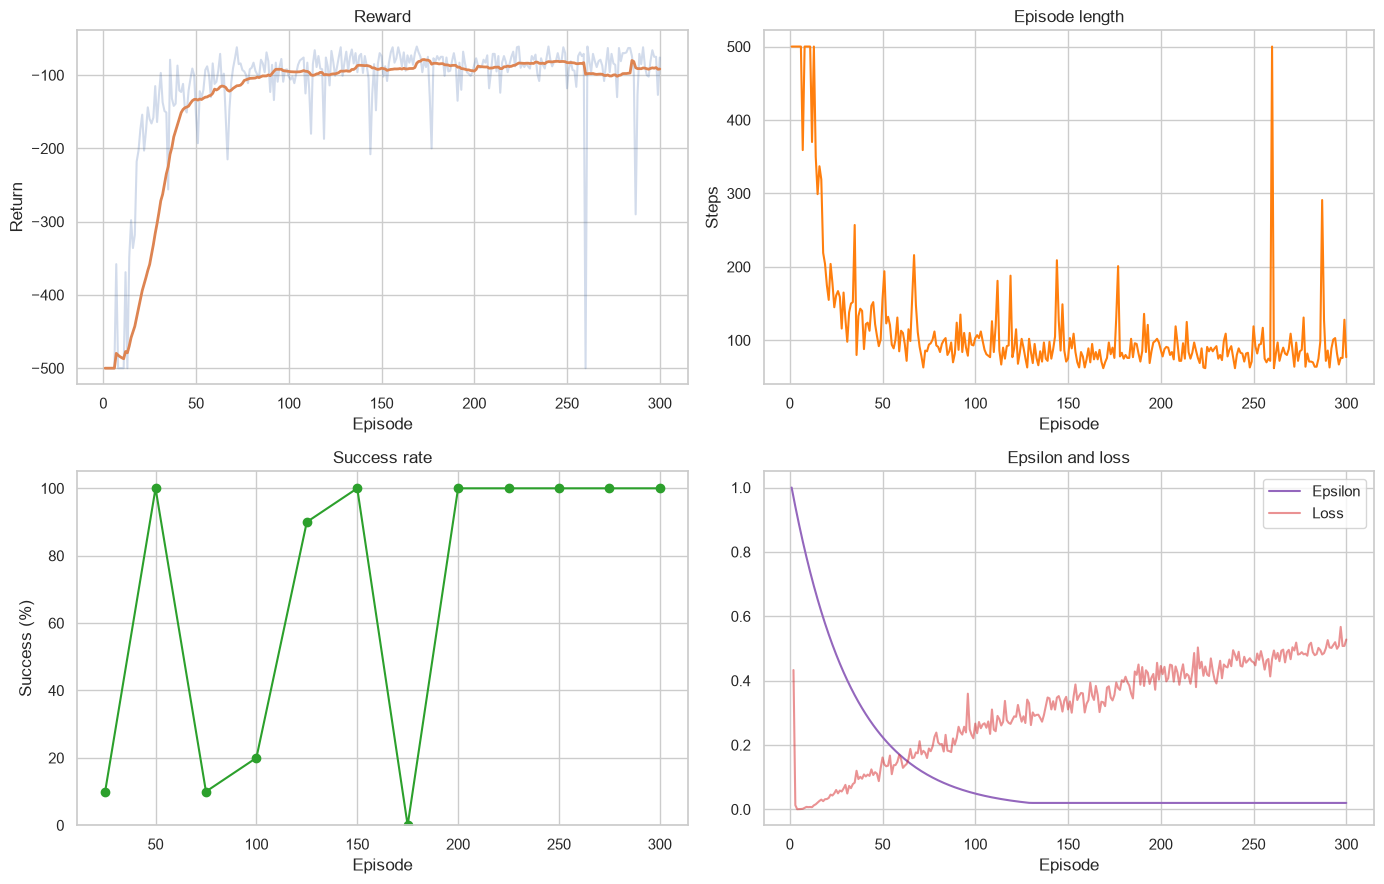

,episodes,mean_reward,last_window_mean_reward,mean_length,overall_success_pct,training_time_sec
0,300,-118.186667,-91.64,119.146667,96.0,231.785289


Exported results to C:\Github\RL-AI572\Assignment_3\notebook_outputs


In [4]:
if not training_df.empty:
    training_df.to_csv(OUTPUT_DIR / "cleaned_episode_results.csv", index=False)
    checkpoint_df.to_csv(OUTPUT_DIR / "checkpoint_success.csv", index=False)
    training_df[["reward", "length", "success", "epsilon", "loss"]].describe().T.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")
    summary = pd.DataFrame([{
        "episodes": len(training_df),
        "mean_reward": training_df.reward.mean(),
        "last_window_mean_reward": training_df.reward.tail(CONFIG["moving_average_window"]).mean(),
        "mean_length": training_df.length.mean(),
        "overall_success_pct": 100 * training_df.success.mean(),
        "training_time_sec": training_seconds,
    }])
    summary.to_csv(OUTPUT_DIR / "model_summary.csv", index=False)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(training_df.episode, training_df.reward, alpha=.25); axes[0, 0].plot(training_df.episode, training_df.reward.rolling(CONFIG["moving_average_window"], min_periods=1).mean(), linewidth=2); axes[0, 0].set(title="Reward", xlabel="Episode", ylabel="Return")
    axes[0, 1].plot(training_df.episode, training_df.length, color="tab:orange"); axes[0, 1].set(title="Episode length", xlabel="Episode", ylabel="Steps")
    axes[1, 0].plot(checkpoint_df.episode, checkpoint_df.success_rate_pct, marker="o", color="tab:green"); axes[1, 0].set(title="Success rate", xlabel="Episode", ylabel="Success (%)", ylim=(0, 105))
    axes[1, 1].plot(training_df.episode, training_df.epsilon, color="tab:purple", label="Epsilon"); axes[1, 1].plot(training_df.episode, training_df.loss, color="tab:red", alpha=.5, label="Loss"); axes[1, 1].set(title="Epsilon and loss", xlabel="Episode"); axes[1, 1].legend()
    fig.tight_layout(); fig.savefig(FIGURES_DIR / "dqn_training_overview.png", dpi=160, bbox_inches="tight"); plt.show()
    display(summary)
    print(f"Exported results to {OUTPUT_DIR.resolve()}")
else:
    print("No data to export.")

## 10. Compare the Three Acrobot Algorithms

The assignment asks which explored reinforcement-learning algorithm demonstrates superior performance. Higher reward is better because it is closer to zero. The Actor-Critic and Q-Actor-Critic values come from their saved evaluation summaries; DQN uses the fresh 30-episode greedy evaluation when `RUN_TRAINING = True`. All three are evaluated without exploration, so the comparison is like-for-like. The conclusion printed below is computed from the table rather than hard-coded.


In [7]:
actor_summary = pd.read_csv(ASSIGNMENT_DIR.parent / "Assignment_2" / "summary_metrics_actor_critic.csv").iloc[0]
qac_summary = pd.read_csv(ASSIGNMENT_DIR.parent / "Assignment_2" / "summary_qac_optimized.csv").iloc[0]

if dqn_eval_metrics is not None:
    dqn_row = {
        "algorithm": "DQN",
        "evaluation_basis": "30 greedy episodes",
        "mean_reward": dqn_eval_metrics["mean_reward"],
        "success_rate_pct": dqn_eval_metrics["success_rate_pct"],
        "mean_episode_length": dqn_eval_metrics["mean_episode_length"],
    }
else:
    dqn_window = training_df.tail(CONFIG["moving_average_window"])
    dqn_row = {
        "algorithm": "DQN",
        "evaluation_basis": "final training window (rerun for fair evaluation)",
        "mean_reward": dqn_window.reward.mean(),
        "success_rate_pct": 100 * dqn_window.success.mean(),
        "mean_episode_length": dqn_window.length.mean(),
    }

comparison_df = pd.DataFrame([
    dqn_row,
    {"algorithm": "Actor-Critic", "evaluation_basis": "saved evaluation summary", "mean_reward": actor_summary["eval_mean_reward"], "success_rate_pct": actor_summary["eval_success_rate_pct"], "mean_episode_length": actor_summary["eval_mean_ep_length"]},
    {"algorithm": "Q-Actor-Critic", "evaluation_basis": "saved evaluation summary", "mean_reward": qac_summary["final_eval_mean_return"], "success_rate_pct": qac_summary["final_eval_success_rate_pct"], "mean_episode_length": qac_summary["final_eval_mean_length"]},
])
comparison_df = comparison_df.sort_values("mean_reward", ascending=False).reset_index(drop=True)
comparison_df.to_csv(OUTPUT_DIR / "algorithm_comparison.csv", index=False)
display(comparison_df)

best, runner_up = comparison_df.iloc[0], comparison_df.iloc[1]
print(f"Superior algorithm by mean evaluation reward: {best.algorithm} ({best.mean_reward:.2f}), "
      f"ahead of {runner_up.algorithm} ({runner_up.mean_reward:.2f}) by {best.mean_reward - runner_up.mean_reward:.2f} reward "
      f"and {runner_up.mean_episode_length - best.mean_episode_length:.1f} fewer steps per episode.")
if comparison_df.success_rate_pct.nunique() == 1:
    print(f"All three algorithms reach {comparison_df.success_rate_pct.iloc[0]:.0f}% success, so mean reward and episode "
          "length (not success rate) are the metrics that separate them.")
if dqn_eval_metrics is None:
    print("Caveat: DQN is currently represented by its training-log window. Run the training cell to compare all algorithms using greedy evaluation episodes.")


,algorithm,evaluation_basis,mean_reward,success_rate_pct,mean_episode_length
0,DQN,30 greedy episodes,-79.133333,100.0,80.133333
1,Actor-Critic,saved evaluation summary,-87.060000,100.0,88.100000
2,Q-Actor-Critic,saved evaluation summary,-160.390000,100.0,161.390000


Superior algorithm by mean evaluation reward: DQN (-79.13), ahead of Actor-Critic (-87.06) by 7.93 reward and 8.0 fewer steps per episode.
All three algorithms reach 100% success, so mean reward and episode length (not success rate) are the metrics that separate them.


## Submission Checklist

- The DQN algorithm is implemented in PyTorch for `Acrobot-v1`.
- Reward, moving-average reward, episode length, success rate, epsilon, and loss are reported.
- The three algorithms are compared using reward, success rate, and episode length.
- CSV summaries and PNG figures are exported to `Assignment_3/notebook_outputs`.
- Export this executed notebook to PDF for the required submission format.